
# ADRD User Evaluation Survey Analysis

This notebook cleans the survey data, filters out responses that should not be included in the evaluation sample, standardizes overlapping role labels, and produces analysis focused on:

- **System usability**
- **Perceived usefulness and acceptance**
- **Trust, anxiety, and perceived risk**
- **Role-based differences in responses**
- **Open-text feedback on strengths, concerns, and improvements**

The cleaning rules applied here follow the thesis criteria:

1. Remove responses where the participant answered **"No"** to interaction with an ADRD patient **unless** their role is a **medical expert / physician / nurse / allied medical professional**.
2. Standardize overlapping role labels such as **"Retired nurse" → "Nurse"**.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import re

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)


In [2]:

# Update this path if needed
csv_path = Path('/Users/alexandrakhreiche/Desktop/Capstone_Code/tests/AI Home Support System for ADRD Care – User Evaluation Survey  (Responses) - Form responses 1.csv')

df_raw = pd.read_csv(csv_path)
print(f'Raw dataset shape: {df_raw.shape}')
df_raw.head(3)


Raw dataset shape: (24, 35)


,Timestamp,Q1. What is your role?,Q2. Have you interacted with a patient with Alzheimer's Disease?,Q3. What is your age group?,Q4. The system interface is visually clear and easy to understand,Q5. The avatar feels natural and comforting,Q6. The design is appropriate for elderly users,Q7. The system feels easy to interact with,Q8. The system feels engaging,Q9. First impression of the system,Q10. The system would help improve patient safety,Q11. The reminder system is useful for daily routines,Q12. The emotional interaction (avatar) is valuable,Q13. The system reduces caregiver burden,Q14. The system responds appropriately to situations,Q15. Which feature did you find most useful?,Q16. Which feature needs improvement?,Q17. I am concerned about the system making incorrect decisions,Q18. I am concerned about over-reliance on the system,Q19. I am concerned about privacy and data security,Q20. I believe the system could cause emotional discomfort,Q21. What risks or concerns do you see in this system?,Q22. I would consider using this system,Q23. I would recommend this system to others,Q24. I believe this system adds value to ADRD care,Q25. How likely are you to recommend this system?,Q26. I feel nervous when using AI-based systems like this,Q27. I find systems like this intimidating,Q28. I feel uncomfortable relying on this technology,Q29. I would need assistance to use this system,Q30. I would trust this system more if recommended by a doctor,Q31. I would trust this system more if it was designed alongside a medical professional,Q32. What would you improve in this system?,Q33. Are there any features not represented that you believe would add additional value to the system?,Q34. Any additional comments?
0,19/03/2026 10:40:39,Family caregiver,Yes,18-25,4,3,4,4,5,"My first impression of the system, is that it tackles a lot of the important features that an ADRD patient might str...",4,5,4,4,4,Safety and Reminder tools,"Avatar image, would like something that flows better.",3,2,2,1,The main risk I see is that the patient just walks away and ignores the system.,4,4,5,5,1,3,2,2,4,4,I think everything works very good but the avatar could be slightly improved.,"nope, you have every feature, you could add mental games eventually.",nope :)
1,19/03/2026 11:45:54,Family caregiver,Yes,18-25,5,5,5,5,5,This is very well thought out. This is especially useful for us care takers. Gives us an inside of what is happening...,5,5,5,5,5,The insight tool,Unfortunately I have no improvement comments. So far the demo has checked all the boxes.,1,4,2,2,I don’t not see risks.,5,5,5,5,2,2,2,4,4,4,No improvement comments,All areas were covered,NaN
2,19/03/2026 11:48:36,Family caregiver,No,55+,5,5,5,4,5,Helpful,5,5,5,4,4,Avatar personal\n,Speed of response,3,2,1,2,NaN,5,5,5,5,1,1,2,2,2,3,Multi cameras,Family members resemblence,NaN


## 1. Define key columns and cleaning functions

In [19]:

role_col = 'Q1. What is your role?'
interacted_col = "Q2. Have you interacted with a patient with Alzheimer's Disease? "
age_col = 'Q3. What is your age group?'

usability_cols = [
    'Q4. The system interface is visually clear and easy to understand',
    'Q5. The avatar feels natural and comforting',
    'Q6. The design is appropriate for elderly users',
    'Q7. The system feels easy to interact with',
    'Q8. The system feels engaging',
]

usefulness_cols = [
    'Q10. The system would help improve patient safety',
    'Q11. The reminder system is useful for daily routines',
    'Q12. The emotional interaction (avatar) is valuable',
    'Q13. The system reduces caregiver burden',
    'Q14. The system responds appropriately to situations',
    'Q22. I would consider using this system',
    'Q23. I would recommend this system to others',
    'Q24. I believe this system adds value to ADRD care',
    'Q25. How likely are you to recommend this system?',
]

risk_cols = [
    'Q17. I am concerned about the system making incorrect decisions',
    'Q18. I am concerned about over-reliance on the system',
    'Q19. I am concerned about privacy and data security',
    'Q20. I believe the system could cause emotional discomfort',
]

anxiety_cols = [
    'Q26. I feel nervous when using AI-based systems like this',
    'Q27. I find systems like this intimidating',
    'Q28. I feel uncomfortable relying on this technology',
    'Q29. I would need assistance to use this system',
]

expert_advice_cols = [
    'Q30. I would trust this system more if recommended by a doctor',
    'Q31. I would trust this system more if it was designed alongside a medical professional ',
]

open_text_cols = [
    'Q9. First impression of the system',
    'Q15. Which feature did you find most useful?',
    'Q16. Which feature needs improvement?',
    'Q21. What risks or concerns do you see in this system? ',
    'Q32. What would you improve in this system?',
    'Q33. Are there any features not represented that you believe would add additional value to the system?',
    'Q34. Any additional comments?'
]

def normalize_role(role):
    if pd.isna(role):
        return np.nan
    r = str(role).strip().lower()
    if 'physician' in r or 'doctor' in r:
        return 'Physician'
    if 'nurse' in r:
        return 'Nurse'
    if 'allied medical' in r:
        return 'Allied Medical Professional'
    if 'professional caregiver' in r:
        return 'Professional Caregiver'
    if 'family caregiver' in r and 'patient relative' in r:
        return 'Patient Relative'
    if 'family caregiver' in r:
        return 'Family Caregiver'
    if 'patient relative' in r or 'relative' in r:
        return 'Patient Relative'
    return str(role).strip().title()

medical_expert_roles = {
    'Physician', 'Nurse', 'Allied Medical Professional'
}

def normalize_yes_no(value):
    if pd.isna(value):
        return np.nan
    v = str(value).strip().lower()
    if v in {'yes', 'y'}:
        return 'Yes'
    if v in {'no', 'n'}:
        return 'No'
    return str(value).strip()

def cronbach_alpha(frame):
    data = frame.dropna()
    k = data.shape[1]
    if k < 2 or len(data) < 2:
        return np.nan
    item_variances = data.var(axis=0, ddof=1)
    total_scores = data.sum(axis=1)
    total_variance = total_scores.var(ddof=1)
    if total_variance == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_variances.sum() / total_variance)


## 2. Clean roles, filter the sample, and inspect exclusions

In [20]:
df = df_raw.copy()
df['role_clean'] = df[role_col].apply(normalize_role)
df['interacted_clean'] = df[interacted_col].apply(normalize_yes_no)

keep_mask = (df['interacted_clean'] == 'Yes') | (df['role_clean'].isin(medical_expert_roles))
excluded = df.loc[~keep_mask, [role_col, 'role_clean', interacted_col, 'interacted_clean']].copy()
df = df.loc[keep_mask].copy()

print(f'Raw responses: {len(df_raw)}')
print(f'Excluded responses: {len(excluded)}')
print(f'Final analysis sample: {len(df)}')
print('\nExcluded rows:')
display(excluded if len(excluded) else pd.DataFrame(columns=[role_col, 'role_clean', interacted_col, 'interacted_clean']))

Raw responses: 24
Excluded responses: 2
Final analysis sample: 22

Excluded rows:


,Q1. What is your role?,role_clean,Q2. Have you interacted with a patient with Alzheimer's Disease?,interacted_clean
2,Family caregiver,Family Caregiver,No,No
6,Family caregiver,Family Caregiver,No,No


In [21]:

print('Original role labels:')
display(df_raw[role_col].value_counts(dropna=False).rename_axis('original_role').reset_index(name='count'))

print('Standardized role labels used in the analysis:')
display(df['role_clean'].value_counts().rename_axis('role_clean').reset_index(name='count'))


Original role labels:


,original_role,count
0,Family caregiver,7
1,Physician,5
2,Professional caregiver,4
3,Other Allied Medical Professionals,3
4,Family caregiver / Patient Relative,2
5,Patient relative,1
6,Nurse,1
7,Retired nurse,1


Standardized role labels used in the analysis:


,role_clean,count
0,Family Caregiver,5
1,Physician,5
2,Professional Caregiver,4
3,Patient Relative,3
4,Allied Medical Professional,3
5,Nurse,2


## 3. Convert Likert-scale items to numeric and create composite scores

In [6]:

scale_cols = usability_cols + usefulness_cols + risk_cols + anxiety_cols + expert_advice_cols

for col in scale_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Composite scores (all on the same 1–5 scale)
df['usability_score'] = df[usability_cols].mean(axis=1)
df['usefulness_acceptance_score'] = df[usefulness_cols].mean(axis=1)
df['risk_concern_score'] = df[risk_cols].mean(axis=1)
df['technology_anxiety_score'] = df[anxiety_cols].mean(axis=1)
df['expert_advice_trust_score'] = df[expert_advice_cols].mean(axis=1)

score_cols = [
    'usability_score',
    'usefulness_acceptance_score',
    'risk_concern_score',
    'technology_anxiety_score',
    'expert_advice_trust_score',
]

df[score_cols].head()


,usability_score,usefulness_acceptance_score,risk_concern_score,technology_anxiety_score,expert_advice_trust_score
0,4.0,4.333333,2.00,2.00,4.0
1,5.0,5.000000,2.25,2.50,4.0
3,4.8,4.777778,2.00,2.00,5.0
4,4.8,5.000000,2.00,1.00,3.0
5,5.0,4.666667,1.25,1.75,3.0


## 4. Reliability check for each scale

In [7]:

reliability = pd.DataFrame({
    'Scale': ['Usability', 'Usefulness & Acceptance', 'Risk & Concern', 'Technology Anxiety', 'Expert Advice / Professional Validation'],
    'Items': [len(usability_cols), len(usefulness_cols), len(risk_cols), len(anxiety_cols), len(expert_advice_cols)],
    'Cronbach_alpha': [
        cronbach_alpha(df[usability_cols]),
        cronbach_alpha(df[usefulness_cols]),
        cronbach_alpha(df[risk_cols]),
        cronbach_alpha(df[anxiety_cols]),
        cronbach_alpha(df[expert_advice_cols]),
    ]
})

reliability['Cronbach_alpha'] = reliability['Cronbach_alpha'].round(3)
reliability


,Scale,Items,Cronbach_alpha
0,Usability,5,0.792
1,Usefulness & Acceptance,9,0.894
2,Risk & Concern,4,0.760
3,Technology Anxiety,4,0.716
4,Expert Advice / Professional Validation,2,0.836


## 5. Overall descriptive results

In [8]:

overall_summary = pd.DataFrame({
    'Scale': ['Usability', 'Usefulness & Acceptance', 'Risk & Concern', 'Technology Anxiety', 'Expert Advice / Professional Validation'],
    'Mean': [
        df['usability_score'].mean(),
        df['usefulness_acceptance_score'].mean(),
        df['risk_concern_score'].mean(),
        df['technology_anxiety_score'].mean(),
        df['expert_advice_trust_score'].mean(),
    ],
    'Median': [
        df['usability_score'].median(),
        df['usefulness_acceptance_score'].median(),
        df['risk_concern_score'].median(),
        df['technology_anxiety_score'].median(),
        df['expert_advice_trust_score'].median(),
    ],
    'Std': [
        df['usability_score'].std(),
        df['usefulness_acceptance_score'].std(),
        df['risk_concern_score'].std(),
        df['technology_anxiety_score'].std(),
        df['expert_advice_trust_score'].std(),
    ],
    'Min': [
        df['usability_score'].min(),
        df['usefulness_acceptance_score'].min(),
        df['risk_concern_score'].min(),
        df['technology_anxiety_score'].min(),
        df['expert_advice_trust_score'].min(),
    ],
    'Max': [
        df['usability_score'].max(),
        df['usefulness_acceptance_score'].max(),
        df['risk_concern_score'].max(),
        df['technology_anxiety_score'].max(),
        df['expert_advice_trust_score'].max(),
    ],
    'N': [df[c].notna().sum() for c in score_cols],
})

overall_summary = overall_summary.round(3)
overall_summary


,Scale,Mean,Median,Std,Min,Max,N
0,Usability,4.300,4.200,0.500,3.400,5.0,22
1,Usefulness & Acceptance,4.369,4.444,0.516,3.222,5.0,22
2,Risk & Concern,2.614,2.625,0.826,1.000,4.0,22
3,Technology Anxiety,2.489,2.375,0.692,1.000,4.0,22
4,Expert Advice / Professional Validation,4.068,4.000,0.955,2.000,5.0,22


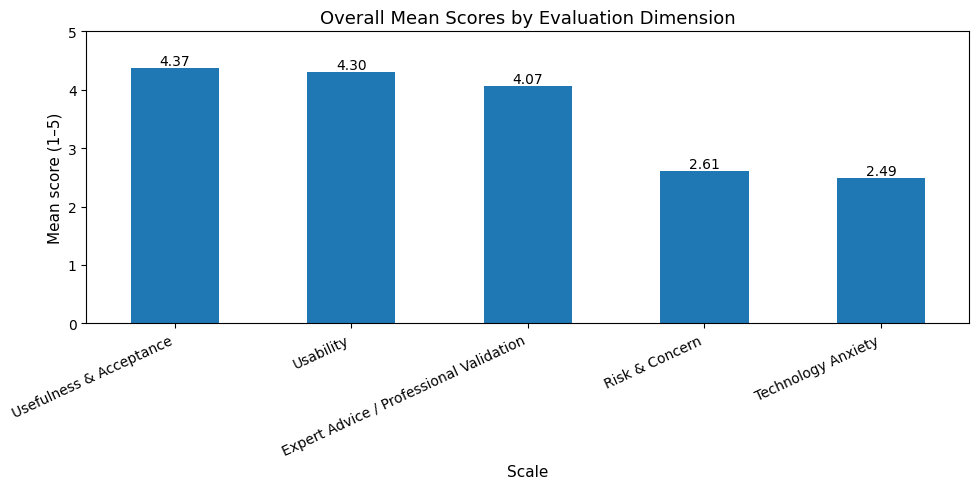

In [9]:

# Plot overall mean scores
plot_data = overall_summary.set_index('Scale')['Mean'].sort_values(ascending=False)
ax = plot_data.plot(kind='bar')
ax.set_ylabel('Mean score (1–5)')
ax.set_title('Overall Mean Scores by Evaluation Dimension')
ax.set_ylim(0, 5)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


## 6. Item-level analysis to identify strongest and weakest areas

In [10]:

item_summary = pd.DataFrame({
    'Item': scale_cols,
    'Mean': [df[c].mean() for c in scale_cols],
    'Median': [df[c].median() for c in scale_cols],
    'Std': [df[c].std() for c in scale_cols],
    'N': [df[c].notna().sum() for c in scale_cols],
})
item_summary = item_summary.round(3).sort_values('Mean', ascending=False)

print('Highest-rated items:')
display(item_summary.head(10))

print('Lowest-rated items:')
display(item_summary.tail(10))


Highest-rated items:


,Item,Mean,Median,Std,N
6,Q11. The reminder system is useful for daily routines,4.773,5.0,0.429,22
0,Q4. The system interface is visually clear and easy to understand,4.636,5.0,0.492,22
5,Q10. The system would help improve patient safety,4.636,5.0,0.581,22
8,Q13. The system reduces caregiver burden,4.455,4.5,0.596,22
12,Q24. I believe this system adds value to ADRD care,4.455,5.0,0.739,22
4,Q8. The system feels engaging,4.364,4.0,0.658,22
7,Q12. The emotional interaction (avatar) is valuable,4.318,4.0,0.780,22
3,Q7. The system feels easy to interact with,4.318,4.0,0.646,22
10,Q22. I would consider using this system,4.227,4.0,0.752,22
13,Q25. How likely are you to recommend this system?,4.182,4.0,0.853,22


Lowest-rated items:


,Item,Mean,Median,Std,N
1,Q5. The avatar feels natural and comforting,4.000,4.0,0.816,22
22,Q30. I would trust this system more if recommended by a doctor,4.000,4.0,1.069,22
15,Q18. I am concerned about over-reliance on the system,2.909,3.0,1.192,22
14,Q17. I am concerned about the system making incorrect decisions,2.727,3.0,0.985,22
18,Q26. I feel nervous when using AI-based systems like this,2.591,3.0,1.098,22
21,Q29. I would need assistance to use this system,2.591,3.0,0.959,22
19,Q27. I find systems like this intimidating,2.500,2.0,0.964,22
16,Q19. I am concerned about privacy and data security,2.455,2.0,1.184,22
17,Q20. I believe the system could cause emotional discomfort,2.364,2.0,0.953,22
20,Q28. I feel uncomfortable relying on this technology,2.273,2.0,0.703,22


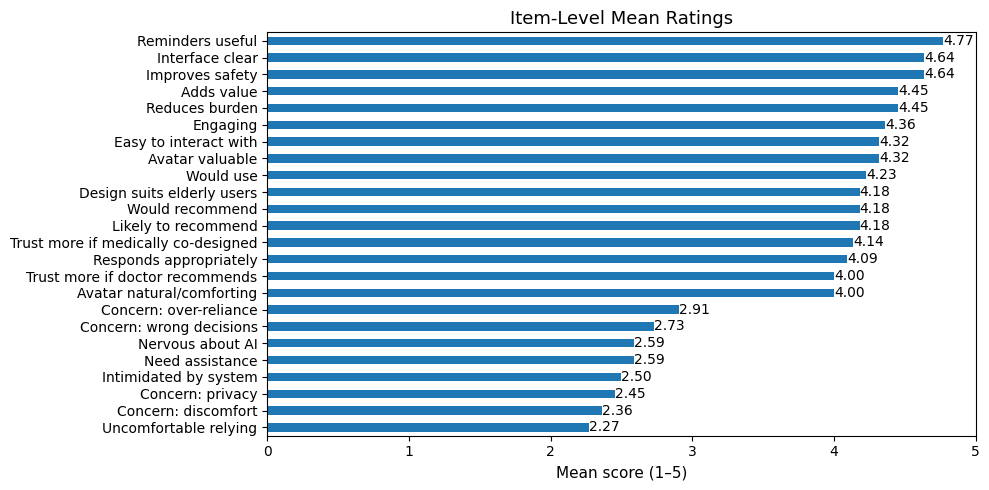

In [11]:

# Short labels for cleaner charts
short_labels = {
    'Q4. The system interface is visually clear and easy to understand': 'Interface clear',
    'Q5. The avatar feels natural and comforting': 'Avatar natural/comforting',
    'Q6. The design is appropriate for elderly users': 'Design suits elderly users',
    'Q7. The system feels easy to interact with': 'Easy to interact with',
    'Q8. The system feels engaging': 'Engaging',
    'Q10. The system would help improve patient safety': 'Improves safety',
    'Q11. The reminder system is useful for daily routines': 'Reminders useful',
    'Q12. The emotional interaction (avatar) is valuable': 'Avatar valuable',
    'Q13. The system reduces caregiver burden': 'Reduces burden',
    'Q14. The system responds appropriately to situations': 'Responds appropriately',
    'Q17. I am concerned about the system making incorrect decisions': 'Concern: wrong decisions',
    'Q18. I am concerned about over-reliance on the system': 'Concern: over-reliance',
    'Q19. I am concerned about privacy and data security': 'Concern: privacy',
    'Q20. I believe the system could cause emotional discomfort': 'Concern: discomfort',
    'Q22. I would consider using this system': 'Would use',
    'Q23. I would recommend this system to others': 'Would recommend',
    'Q24. I believe this system adds value to ADRD care': 'Adds value',
    'Q25. How likely are you to recommend this system?': 'Likely to recommend',
    'Q26. I feel nervous when using AI-based systems like this': 'Nervous about AI',
    'Q27. I find systems like this intimidating': 'Intimidated by system',
    'Q28. I feel uncomfortable relying on this technology': 'Uncomfortable relying',
    'Q29. I would need assistance to use this system': 'Need assistance',
    'Q30. I would trust this system more if recommended by a doctor': 'Trust more if doctor recommends',
    'Q31. I would trust this system more if it was designed alongside a medical professional ': 'Trust more if medically co-designed',
}

item_means = pd.Series({short_labels.get(c, c): df[c].mean() for c in scale_cols}).sort_values()
ax = item_means.plot(kind='barh')
ax.set_xlabel('Mean score (1–5)')
ax.set_title('Item-Level Mean Ratings')
ax.set_xlim(0, 5)
for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}", (p.get_width(), p.get_y() + p.get_height() / 2),
                va='center')
plt.tight_layout()
plt.show()


## 7. Role-based differences

In [12]:

role_summary = df.groupby('role_clean')[score_cols].agg(['mean', 'median', 'count'])
role_summary.round(3)


usability_score               \
                                               mean median count   
role_clean                                                         
Allied Medical Professional                   4.133    4.0     3   
Family Caregiver                              4.760    5.0     5   
Family Caregiver / Patient Relative           3.800    3.8     2   
Nurse                                         4.400    4.4     2   
Patient Relative                              4.800    4.8     1   
Physician                                     3.920    3.8     5   
Professional Caregiver                        4.400    4.5     4   

                                    usefulness_acceptance_score               \
                                                           mean median count   
role_clean                                                                     
Allied Medical Professional                               4.259  4.333     3   
Family Caregiver                                          4.689  4.667     5   
Family Caregiver / Patient Relative                       4.333  4.333     2   
Nurse                                                     4.167  4.167     2   
Patient Relative                                          5.000  5.000     1   
Physician                                                 3.844  3.444     5   
Professional Caregiver                                    4.667  4.722     4   

                                    risk_concern_score               \
                                                  mean median count   
role_clean                                                            
Allied Medical Professional                      2.083  2.000     3   
Family Caregiver                                 2.150  2.000     5   
Family Caregiver / Patient Relative              2.625  2.625     2   
Nurse                                            2.750  2.750     2   
Patient Relative                                 2.000  2.000     1   
Physician                                        3.200  3.500     5   
Professional Caregiver                           2.938  2.875     4   

                                    technology_anxiety_score               \
                                                        mean median count   
role_clean                                                                  
Allied Medical Professional                            2.000  2.250     3   
Family Caregiver                                       2.250  2.000     5   
Family Caregiver / Patient Relative                    2.750  2.750     2   
Nurse                                                  3.000  3.000     2   
Patient Relative                                       1.000  1.000     1   
Physician                                              3.100  3.250     5   
Professional Caregiver                                 2.375  2.125     4   

                                    expert_advice_trust_score               
                                                         mean median count  
role_clean                                                                  
Allied Medical Professional                              4.50   5.00     3  
Family Caregiver                                         4.00   4.00     5  
Family Caregiver / Patient Relative                      5.00   5.00     2  
Nurse                                                    3.75   3.75     2  
Patient Relative                                         3.00   3.00     1  
Physician                                                3.90   4.00     5  
Professional Caregiver                                   4.00   4.50     4

In [13]:

role_means = df.groupby('role_clean')[score_cols].mean().round(3)
role_means


,usability_score,usefulness_acceptance_score,risk_concern_score,technology_anxiety_score,expert_advice_trust_score
role_clean,,,,,
Allied Medical Professional,4.133,4.259,2.083,2.000,4.50
Family Caregiver,4.760,4.689,2.150,2.250,4.00
Family Caregiver / Patient Relative,3.800,4.333,2.625,2.750,5.00
Nurse,4.400,4.167,2.750,3.000,3.75
Patient Relative,4.800,5.000,2.000,1.000,3.00
Physician,3.920,3.844,3.200,3.100,3.90
Professional Caregiver,4.400,4.667,2.938,2.375,4.00


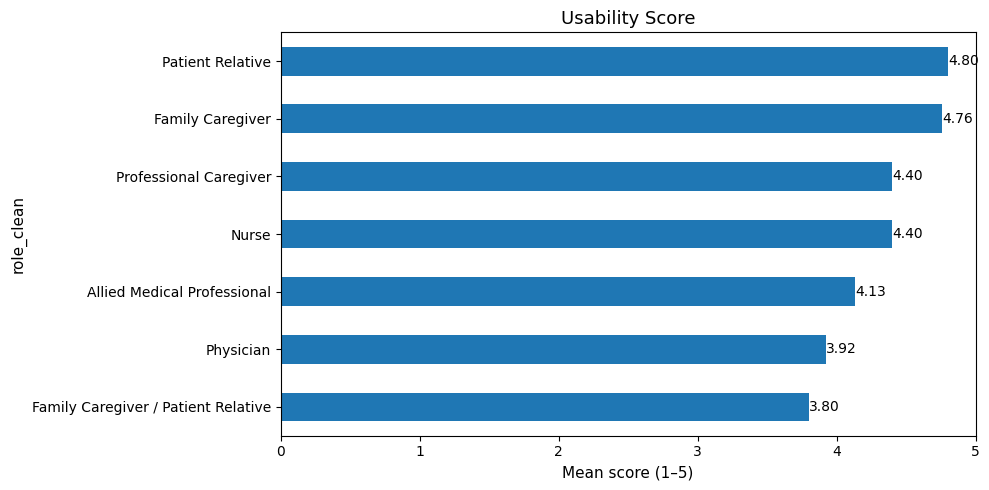

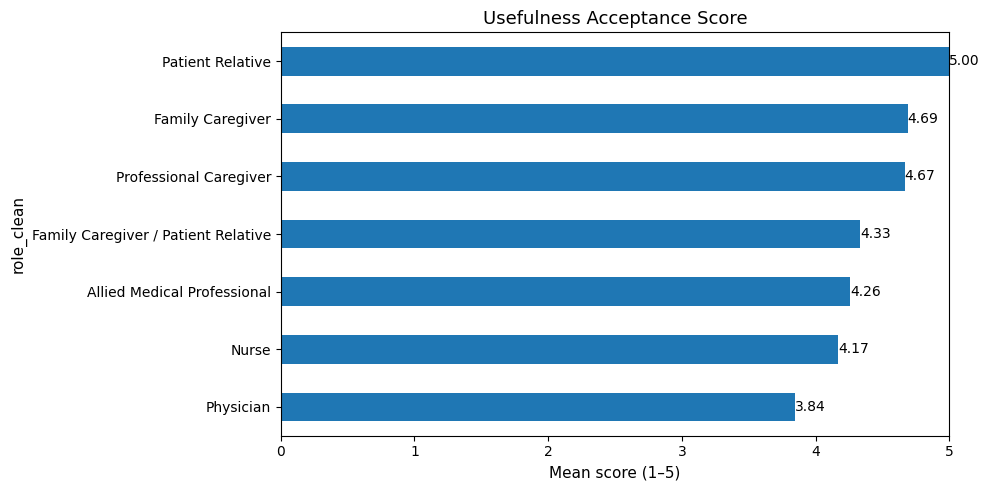

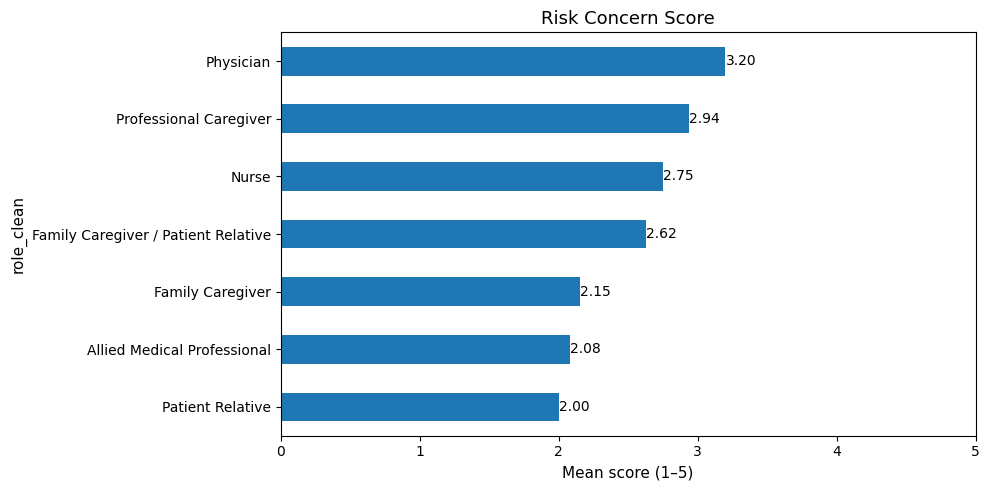

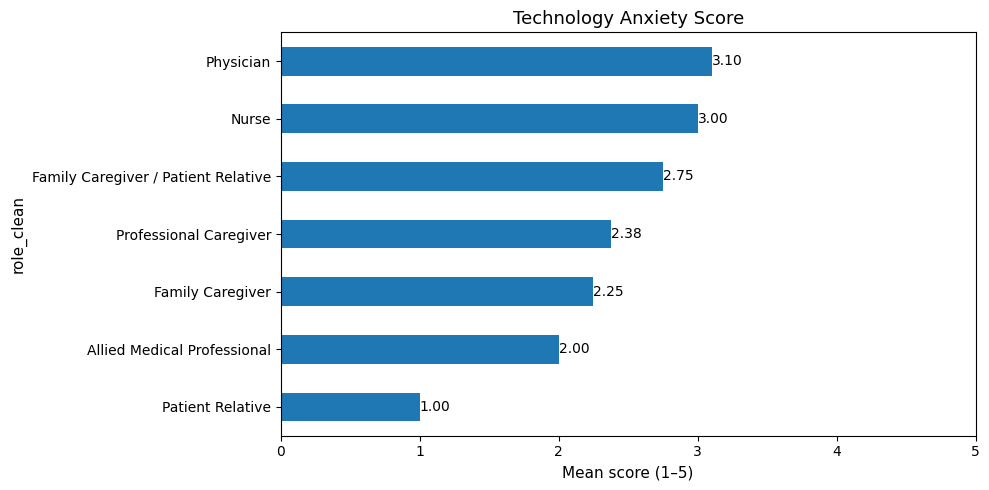

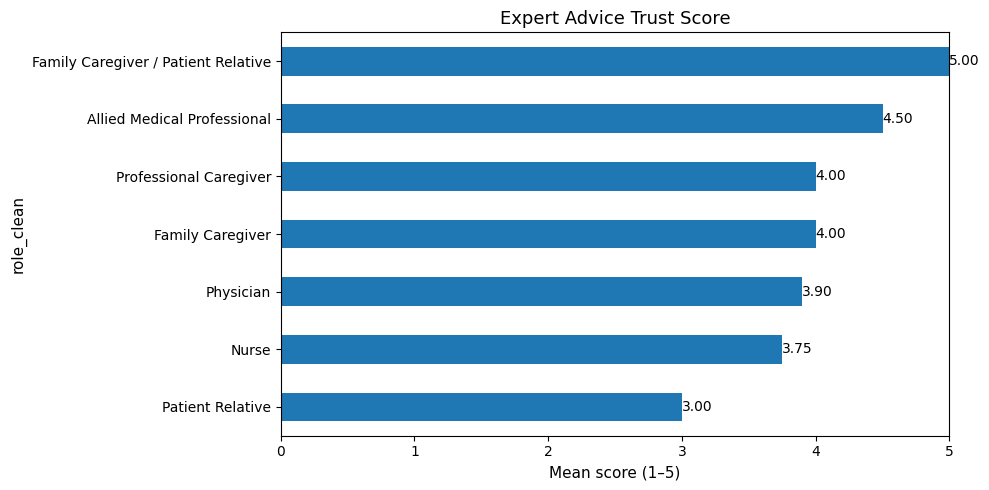

In [14]:

# Plot one chart per score for readability
for score in score_cols:
    series = df.groupby('role_clean')[score].mean().sort_values()
    ax = series.plot(kind='barh')
    ax.set_title(score.replace('_', ' ').title())
    ax.set_xlabel('Mean score (1–5)')
    ax.set_xlim(0, 5)
    for p in ax.patches:
        ax.annotate(f"{p.get_width():.2f}", (p.get_width(), p.get_y() + p.get_height() / 2),
                    va='center')
    plt.tight_layout()
    plt.show()


## 8. Distribution of agreement on key outcome items

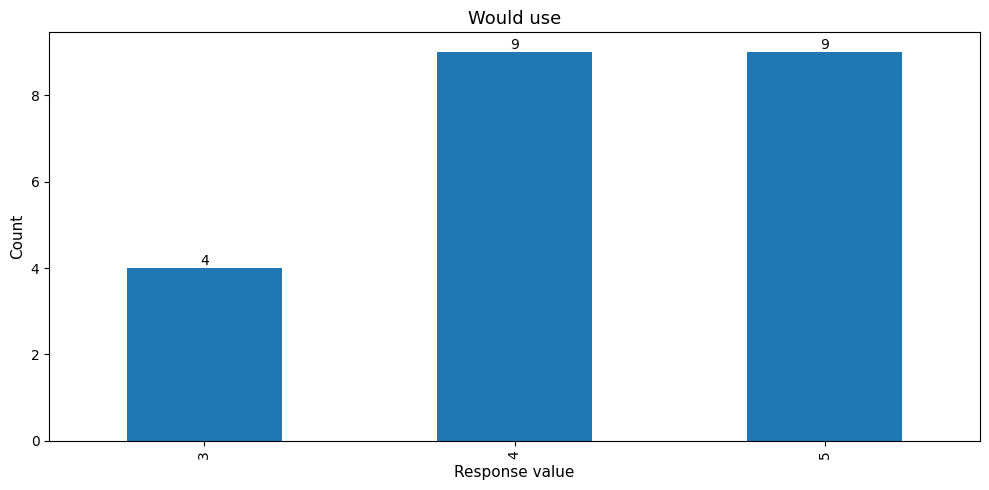

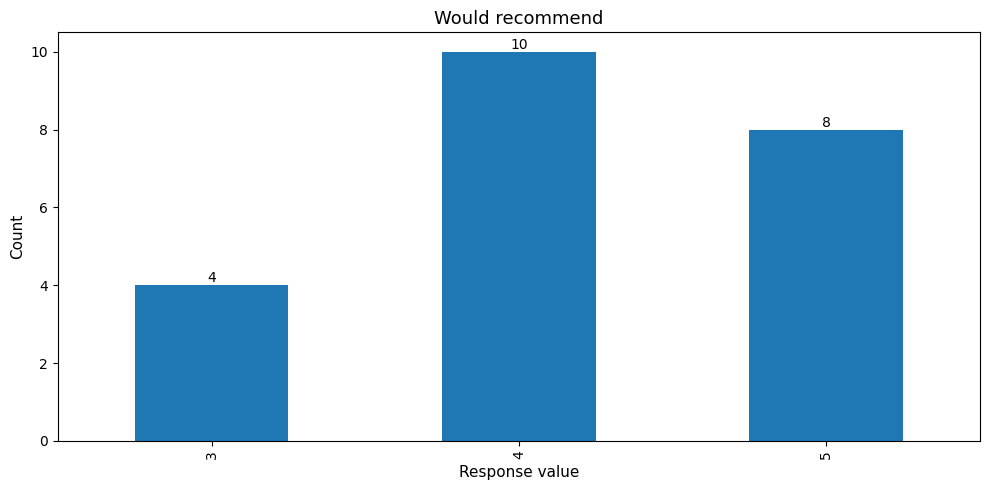

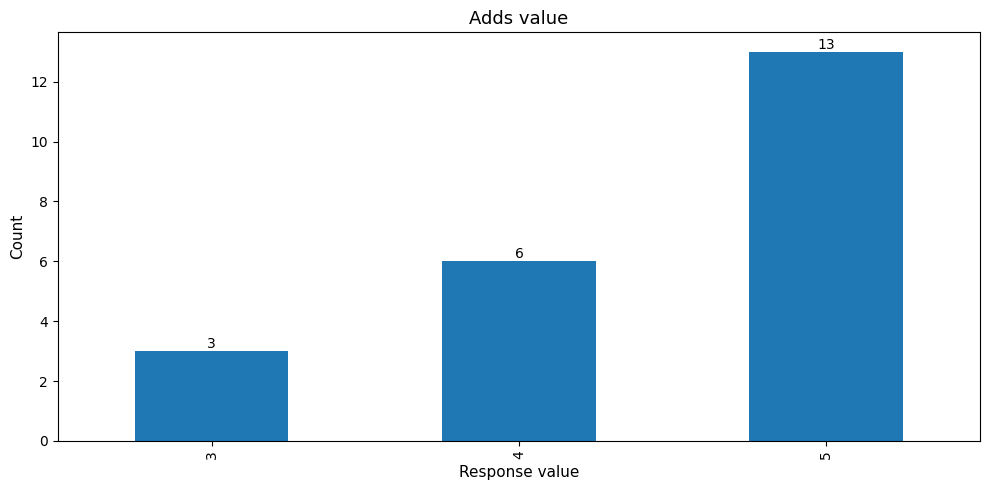

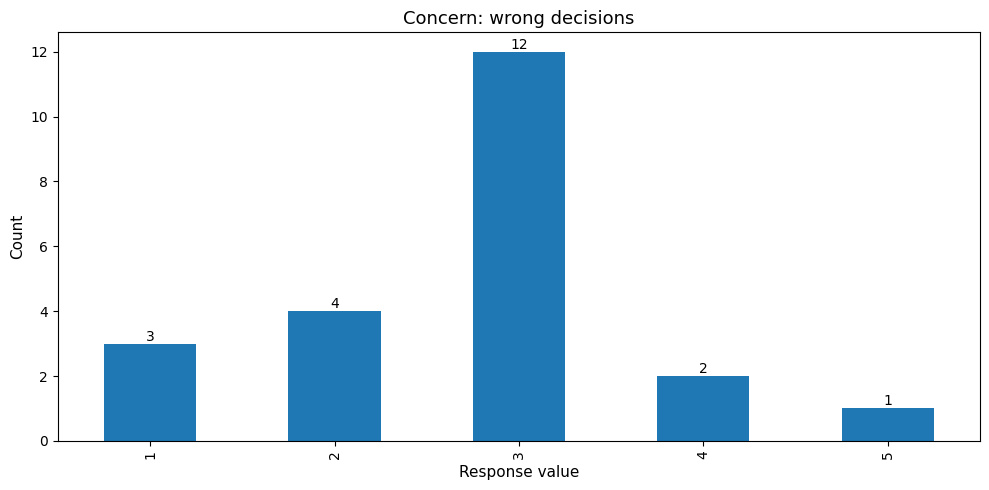

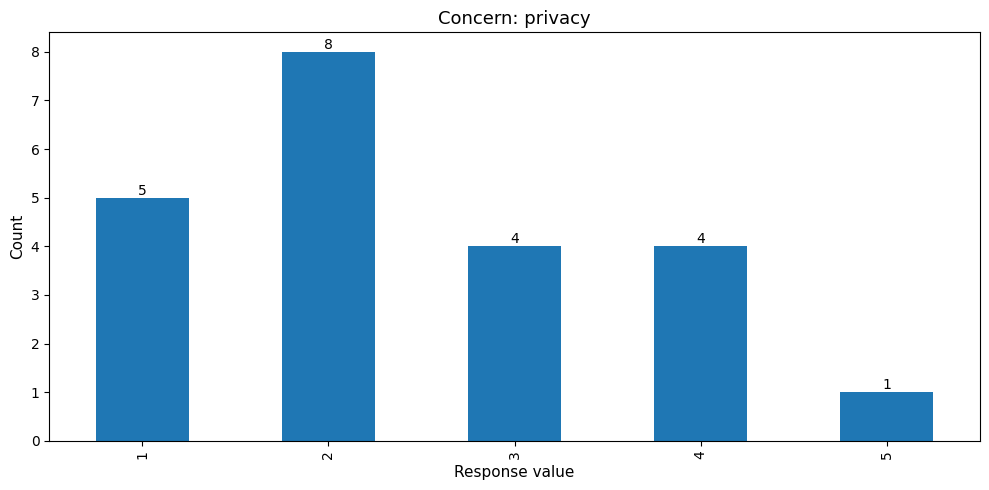

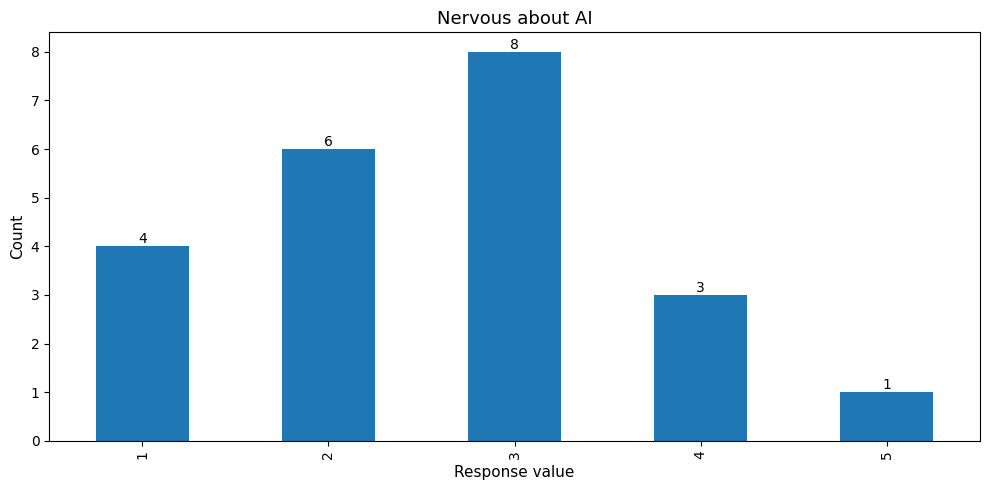

In [15]:

key_items = [
    'Q22. I would consider using this system',
    'Q23. I would recommend this system to others',
    'Q24. I believe this system adds value to ADRD care',
    'Q17. I am concerned about the system making incorrect decisions',
    'Q19. I am concerned about privacy and data security',
    'Q26. I feel nervous when using AI-based systems like this',
]

for item in key_items:
    counts = df[item].value_counts().sort_index()
    ax = counts.plot(kind='bar')
    ax.set_title(short_labels.get(item, item))
    ax.set_xlabel('Response value')
    ax.set_ylabel('Count')
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom')
    plt.tight_layout()
    plt.show()


## 9. Open-text analysis helpers

In [16]:
for col in open_text_cols:
    print(f'\n--- {col} ---')
    display(df[['role_clean', col]].dropna().reset_index(drop=True))


--- Q9. First impression of the system ---


,role_clean,Q9. First impression of the system
0,Family Caregiver,"My first impression of the system, is that it tackles a lot of the important features that an ADRD patient might str..."
1,Family Caregiver,This is very well thought out. This is especially useful for us care takers. Gives us an inside of what is happening...
2,Professional Caregiver,"Great innovation, the lady is very real"
3,Patient Relative,"I think everything about it is great, but perhaps the flow of the avatar’s speech could be smoother and hence more c..."
4,Family Caregiver,"Interaction is always beneficial with patients, and the Maria avatar can fulfill this role provided that human inter..."
5,Family Caregiver,New and good to have it
6,Allied Medical Professional,Promising
7,Professional Caregiver,"Interesting dashboard to log in all patient’s care and status, easy to find pertinent information to plan care accor..."
8,Nurse,Engaging
9,Nurse,I have a question: will the avatar use other laguages?



--- Q15. Which feature did you find most useful? ---


,role_clean,Q15. Which feature did you find most useful?
0,Family Caregiver,Safety and Reminder tools
1,Family Caregiver,The insight tool
2,Professional Caregiver,The lady who speaks
3,Patient Relative,The avatars ability to deal with the patients different emotions as opposed to a fraguare who this type of interacti...
4,Family Caregiver,The reminder system for daily routine.
5,Family Caregiver,The interaction no idea
6,Allied Medical Professional,The personalization
7,Professional Caregiver,The interactive part of the system with the patient. Very innovative and helpful for the patient
8,Nurse,Reminder system
9,Nurse,Burden would be also reduced for family members.



--- Q16. Which feature needs improvement? ---


...

,role_clean,Q32. What would you improve in this system?
0,Family Caregiver,I think everything works very good but the avatar could be slightly improved.
1,Family Caregiver,No improvement comments
2,Professional Caregiver,nothing i could think of
3,Patient Relative,"Firstly, I think the speech quality of the avatar is a bit unnatural and can prevent the patient from communicating ..."
4,Family Caregiver,A connection between the system and the people in charge of the patient such as an alert system if the patient moves...
5,Allied Medical Professional,We should test on elders to see.
6,Professional Caregiver,The system is good as a prototype to start with. It should be tested on real patients in real environments and work ...
7,Nurse,Nil
8,Nurse,"This is something new, but a pilot study will help."
9,Physician,I would pilot the system on institutionalized and supervised patients before using it



--- Q33. Are there any features not represented that you believe would add additional value to the system? ---


,role_clean,Q33. Are there any features not represented that you believe would add additional value to the system?
0,Family Caregiver,"nope, you have every feature, you could add mental games eventually."
1,Family Caregiver,All areas were covered
2,Professional Caregiver,Noi
3,Patient Relative,I believe I mentioned this in my answer above.
4,Family Caregiver,The avatar's face can be designed differently for each patient . It could be inspired by photo of close family membe...
5,Allied Medical Professional,Can't identify any.
6,Professional Caregiver,Medication management such as automated reminders in specific for the patients in early stage of the disease
7,Nurse,How the ADRD system gives a warning if the person escapes whether in a hospital or home settings?
8,Physician,"The avatar's expressions are bland and may cause distress in patients, more facial expressions might help, motion se..."
9,Family Caregiver,could add cognitive games



--- Q34. Any additional comments? ---


,role_clean,Q34. Any additional comments?
0,Family Caregiver,nope :)
1,Professional Caregiver,No
2,Patient Relative,"I think this is a wonderful initiative, and I think the approaches extremely creative and could be extremely benefic..."
3,Family Caregiver,I would like to thank you and encourage you in your work which aims to make life easier for patients and especially ...
4,Family Caregiver,Looking forward to see this in reality
5,Professional Caregiver,A suggestion to integrate this system with the patient medical file for documentation purposes
6,Nurse,Good idea if applied and received properly.
7,Physician,No
8,Family Caregiver,no
9,Professional Caregiver,no


In [17]:

# Lightweight keyword extraction for quick exploratory insight
stopwords = {
    'the','and','to','of','a','is','it','that','this','for','be','with','would','i','in','on','as','are','my','very',
    'or','an','if','so','more','could','not','have','has','but','at','by','from','they','them','their','we','you',
    'system','avatar','patient','patients','caregiver','caregivers'
}

def tokenize_text(series):
    text = ' '.join(series.dropna().astype(str).str.lower())
    tokens = re.findall(r"[a-zA-Z']+", text)
    tokens = [t for t in tokens if len(t) > 2 and t not in stopwords]
    return Counter(tokens)

for col in ['Q15. Which feature did you find most useful?', 'Q16. Which feature needs improvement?', 'Q21. What risks or concerns do you see in this system? ', 'Q32. What would you improve in this system?']:
    counts = tokenize_text(df[col])
    print(f'\nTop words for: {col}')
    print(counts.most_common(15))



Top words for: Q15. Which feature did you find most useful?
[('safety', 3), ('reminder', 3), ('interaction', 3), ('help', 3), ('who', 2), ('ability', 2), ('personalization', 2), ('feel', 2), ('able', 2), ('communicate', 2), ('tools', 1), ('insight', 1), ('tool', 1), ('lady', 1), ('speaks', 1)]

Top words for: Q16. Which feature needs improvement?
[('interaction', 3), ('better', 2), ('clear', 2), ('how', 2), ('will', 2), ('voice', 2), ('songs', 2), ('image', 1), ('like', 1), ('something', 1), ('flows', 1), ('unfortunately', 1), ('improvement', 1), ('comments', 1), ('far', 1)]

Top words for: Q21. What risks or concerns do you see in this system? 
[('cause', 3), ('none', 3), ('see', 2), ('know', 2), ('maybe', 2), ('being', 2), ('scared', 2), ('useful', 2), ('disease', 2), ('lack', 2), ('might', 2), ('human', 2), ('attached', 2), ('hallucinations', 2), ('main', 1)]

Top words for: Q32. What would you improve in this system?
[('think', 3), ('nothing', 3), ('pilot', 3), ('before', 3), ('go

## 10. Significance testing

In [23]:
# Likert columns by factor
factor_items = {
    "Usability": [
        "Q4. The system interface is visually clear and easy to understand",
        "Q5. The avatar feels natural and comforting",
        "Q6. The design is appropriate for elderly users",
        "Q7. The system feels easy to interact with",
        "Q8. The system feels engaging",
    ],
    "Usefulness_Acceptance": [
        "Q10. The system would help improve patient safety",
        "Q11. The reminder system is useful for daily routines",
        "Q12. The emotional interaction (avatar) is valuable",
        "Q13. The system reduces caregiver burden",
        "Q14. The system responds appropriately to situations",
        "Q22. I would consider using this system",
        "Q23. I would recommend this system to others",
        "Q24. I believe this system adds value to ADRD care",
    ],
    "Risk_Concerns": [
        "Q17. I am concerned about the system making incorrect decisions",
        "Q18. I am concerned about over-reliance on the system",
        "Q19. I am concerned about privacy and data security",
        "Q20. I believe the system could cause emotional discomfort",
    ],
    "Technology_Anxiety": [
        "Q26. I feel nervous when using AI-based systems like this",
        "Q27. I find systems like this intimidating",
        "Q28. I feel uncomfortable relying on this technology",
        "Q29. I would need assistance to use this system",
    ],
    "Expert_Advice": [
        "Q30. I would trust this system more if recommended by a doctor",
        "Q31. I would trust this system more if it was designed alongside a medical professional ",
    ]
}

# Convert Likert columns to numeric safely
for cols in factor_items.values():
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Composite factor scores
for factor, cols in factor_items.items():
    df[factor] = df[cols].mean(axis=1)

factor_score_cols = list(factor_items.keys())
df[factor_score_cols].head()

,Usability,Usefulness_Acceptance,Risk_Concerns,Technology_Anxiety,Expert_Advice
0,4.0,4.250,2.00,2.00,4.0
1,5.0,5.000,2.25,2.50,4.0
3,4.8,4.750,2.00,2.00,5.0
4,4.8,5.000,2.00,1.00,3.0
5,5.0,4.625,1.25,1.75,3.0


In [24]:
from scipy import stats

NEUTRAL_MIDPOINT = 3

# ---------- One-sample t-tests vs neutral midpoint ----------
one_sample_results = []

for factor in factor_score_cols:
    scores = df[factor].dropna()
    n = len(scores)
    mean_val = scores.mean()
    sd_val = scores.std(ddof=1)

    if n >= 2:
        t_stat, p_val = stats.ttest_1samp(scores, popmean=NEUTRAL_MIDPOINT, nan_policy="omit")
        # Cohen's d for one-sample test
        cohen_d = (mean_val - NEUTRAL_MIDPOINT) / sd_val if sd_val != 0 else np.nan
    else:
        t_stat, p_val, cohen_d = np.nan, np.nan, np.nan

    one_sample_results.append({
        "Factor": factor,
        "N": n,
        "Mean": round(mean_val, 3),
        "SD": round(sd_val, 3) if pd.notna(sd_val) else np.nan,
        "Test Value": NEUTRAL_MIDPOINT,
        "t-statistic": round(t_stat, 3) if pd.notna(t_stat) else np.nan,
        "p-value": round(p_val, 4) if pd.notna(p_val) else np.nan,
        "Cohen_d": round(cohen_d, 3) if pd.notna(cohen_d) else np.nan,
        "Significant_at_0.05": bool(p_val < 0.05) if pd.notna(p_val) else np.nan,
        "Direction_vs_Neutral": (
            "Above neutral" if mean_val > NEUTRAL_MIDPOINT else
            "Below neutral" if mean_val < NEUTRAL_MIDPOINT else
            "Equal to neutral"
        )
    })

one_sample_results_df = pd.DataFrame(one_sample_results)
display(one_sample_results_df)

,Factor,N,Mean,SD,Test Value,t-statistic,p-value,Cohen_d,Significant_at_0.05,Direction_vs_Neutral
0,Usability,22,4.300,0.500,3,12.183,0.0000,2.598,True,Above neutral
1,Usefulness_Acceptance,22,4.392,0.491,3,13.286,0.0000,2.833,True,Above neutral
2,Risk_Concerns,22,2.614,0.826,3,-2.193,0.0397,-0.468,True,Below neutral
3,Technology_Anxiety,22,2.489,0.692,3,-3.465,0.0023,-0.739,True,Below neutral
4,Expert_Advice,22,4.068,0.955,3,5.247,0.0000,1.119,True,Above neutral


In [27]:
def interpret_p(p):
    if pd.isna(p):
        return "Not tested"
    elif p < 0.001:
        return "*** p < .001"
    elif p < 0.01:
        return "** p < .01"
    elif p < 0.05:
        return "* p < .05"
    else:
        return "ns"

summary_for_thesis = one_sample_results_df.copy()
summary_for_thesis["Sig_Label"] = summary_for_thesis["p-value"].apply(interpret_p)
summary_for_thesis = summary_for_thesis[
    ["Factor", "N", "Mean", "SD", "t-statistic", "p-value", "Sig_Label", "Cohen_d", "Direction_vs_Neutral"]
]

display(summary_for_thesis)

,Factor,N,Mean,SD,t-statistic,p-value,Sig_Label,Cohen_d,Direction_vs_Neutral
0,Usability,22,4.300,0.500,12.183,0.0000,*** p < .001,2.598,Above neutral
1,Usefulness_Acceptance,22,4.392,0.491,13.286,0.0000,*** p < .001,2.833,Above neutral
2,Risk_Concerns,22,2.614,0.826,-2.193,0.0397,* p < .05,-0.468,Below neutral
3,Technology_Anxiety,22,2.489,0.692,-3.465,0.0023,** p < .01,-0.739,Below neutral
4,Expert_Advice,22,4.068,0.955,5.247,0.0000,*** p < .001,1.119,Above neutral



## 11. Suggested interpretation structure for the thesis

After running the notebook, you can write up the results in this order:

1. **Sample cleaning and final N**
   - Explain how many responses were excluded and why.
   - Report the final sample size and role distribution.

2. **Overall usability**
   - Use the **usability score** and the highest/lowest usability items.
   - Mention whether the interface, engagement, and elderly-appropriate design were rated positively.

3. **Acceptance and perceived value**
   - Report the **usefulness & acceptance score**.
   - Highlight safety, reminders, emotional interaction, burden reduction, and recommendation intent.

4. **Concerns and barriers**
   - Report **risk/concern** and **technology anxiety**.
   - Identify whether trust depends on medical endorsement or co-design.

5. **Role-based insights**
   - Compare family caregivers, professional caregivers, nurses, physicians, and allied professionals.

6. **Open-text themes**
   - Use the open-text tables to manually code recurring themes such as:
     - avatar naturalness / speech quality
     - safety and reminders as strongest features
     - privacy or incorrect-decision concerns
     - desire for personalization or additional family/context input
